# 09 Llm As A Judge Engine

**Project:** LLMOps Monitoring & Evaluation Platform

**Notebook:** `09-llm-as-a-judge-engine.ipynb`

In [22]:
# ==========================================
# Notebook 09
# LLM-as-a-Judge Engine
# ==========================================

import json

import pandas as pd

from transformers import pipeline

In [23]:
df = pd.read_csv("../data/golden_dataset.csv")

df.head()

,question,contexts,generated_response,ground_truth,question_length,answer_length
0,What is AWS?,AWS stands for Amazon Web Services. It is a cl...,AWS is Amazon's cloud platform.,"AWS is Amazon Web Services, a cloud computing ...",12.0,55.0
1,What is Azure?,Microsoft Azure is a cloud platform offered by...,Azure is Microsoft's cloud service.,Microsoft Azure is a cloud computing platform ...,14.0,67.0
2,What is Google Cloud?,Google Cloud Platform provides cloud computing...,Google Cloud offers cloud services.,Google Cloud Platform provides cloud computing...,21.0,56.0
3,What is AWS?,AWS is a cloud platform.,AWS provides cloud services.,AWS is a cloud computing platform.,NaN,NaN
4,What is Azure?,Azure is a cloud platform.,Azure provides cloud services.,Azure is a cloud computing platform.,NaN,NaN


In [24]:
judge_llm = pipeline(
    "text-generation", model="Qwen/Qwen2.5-1.5B-Instruct", max_new_tokens=300
)

Device set to use cpu


In [25]:
question = "What is AWS?"

ground_truth = """
AWS is Amazon Web Services,
a cloud computing platform.
"""

generated_response = """
AWS is Amazon's cloud platform.
"""

In [26]:
evaluation_rubric = """
Evaluate the response using:

1. Correctness
2. Completeness
3. Relevance
4. Clarity

Score each category from 1-10.

Return JSON only.
"""

In [27]:
def build_judge_prompt(question, ground_truth, generated_response):

    prompt = f"""
You are an expert evaluator.

Question:
{question}

Ground Truth:
{ground_truth}

Generated Response:
{generated_response}

{evaluation_rubric}

Return format:

{{
  "correctness": 0,
  "completeness": 0,
  "relevance": 0,
  "clarity": 0,
  "overall_score": 0,
  "reason": ""
}}
"""

    return prompt

In [28]:
prompt = build_judge_prompt(question, ground_truth, generated_response)

print(prompt)


You are an expert evaluator.

Question:
What is AWS?

Ground Truth:

AWS is Amazon Web Services,
a cloud computing platform.


Generated Response:

AWS is Amazon's cloud platform.



Evaluate the response using:

1. Correctness
2. Completeness
3. Relevance
4. Clarity

Score each category from 1-10.

Return JSON only.


Return format:

{
  "correctness": 0,
  "completeness": 0,
  "relevance": 0,
  "clarity": 0,
  "overall_score": 0,
  "reason": ""
}



In [29]:
result = judge_llm(prompt)

In [30]:
judge_output = result[0]["generated_text"]

print(judge_output)


You are an expert evaluator.

Question:
What is AWS?

Ground Truth:

AWS is Amazon Web Services,
a cloud computing platform.


Generated Response:

AWS is Amazon's cloud platform.



Evaluate the response using:

1. Correctness
2. Completeness
3. Relevance
4. Clarity

Score each category from 1-10.

Return JSON only.


Return format:

{
  "correctness": 0,
  "completeness": 0,
  "relevance": 0,
  "clarity": 0,
  "overall_score": 0,
  "reason": ""
}
```json
{
  "correctness": 8,
  "completeness": 9,
  "relevance": 9,
  "clarity": 7,
  "overall_score": 8,
  "reason": "The response accurately defines AWS as a cloud computing platform provided by Amazon."
}


In [31]:
import re

In [32]:
def extract_json(text):

    match = re.search(r"\{.*\}", text, re.DOTALL)

    if match:

        return match.group()

    return None

In [33]:
json_text = extract_json(judge_output)

json_text

'{\n  "correctness": 0,\n  "completeness": 0,\n  "relevance": 0,\n  "clarity": 0,\n  "overall_score": 0,\n  "reason": ""\n}\n```json\n{\n  "correctness": 8,\n  "completeness": 9,\n  "relevance": 9,\n  "clarity": 7,\n  "overall_score": 8,\n  "reason": "The response accurately defines AWS as a cloud computing platform provided by Amazon."\n}'

In [34]:
try:

    scores = json.loads(json_text)

except Exception:

    scores = {}

In [35]:
scores

{}

In [36]:
{
    "correctness": 8,
    "completeness": 7,
    "relevance": 9,
    "clarity": 8,
    "overall_score": 8,
    "reason": "...",
}

{'correctness': 8,
 'completeness': 7,
 'relevance': 9,
 'clarity': 8,
 'overall_score': 8,
 'reason': '...'}

In [37]:
def llm_judge(question, ground_truth, generated_response):

    prompt = build_judge_prompt(question, ground_truth, generated_response)

    result = judge_llm(prompt)

    output = result[0]["generated_text"]

    json_text = extract_json(output)

    try:

        scores = json.loads(json_text)

    except:

        scores = {
            "correctness": 0,
            "completeness": 0,
            "relevance": 0,
            "clarity": 0,
            "overall_score": 0,
            "reason": "Parse Failed",
        }

    return scores

In [38]:
llm_judge(question, ground_truth, generated_response)

{'correctness': 0,
 'completeness': 0,
 'relevance': 0,
 'clarity': 0,
 'overall_score': 0,
 'reason': 'Parse Failed'}

In [39]:
judge_results = []

In [40]:
for _, row in df.iterrows():

    result = llm_judge(row["question"], row["ground_truth"], row["generated_response"])

    judge_results.append(result)

In [41]:
judge_df = pd.DataFrame(judge_results)

judge_df.head()

,correctness,completeness,relevance,clarity,overall_score,reason
0,0,0,0,0,0,Parse Failed
1,0,0,0,0,0,Parse Failed
2,0,0,0,0,0,Parse Failed
3,0,0,0,0,0,Parse Failed
4,0,0,0,0,0,Parse Failed


In [42]:
evaluation_df = pd.concat([df, judge_df], axis=1)

In [43]:
evaluation_df.head()

,question,contexts,generated_response,ground_truth,question_length,answer_length,correctness,completeness,relevance,clarity,overall_score,reason
0,What is AWS?,AWS stands for Amazon Web Services. It is a cl...,AWS is Amazon's cloud platform.,"AWS is Amazon Web Services, a cloud computing ...",12.0,55.0,0,0,0,0,0,Parse Failed
1,What is Azure?,Microsoft Azure is a cloud platform offered by...,Azure is Microsoft's cloud service.,Microsoft Azure is a cloud computing platform ...,14.0,67.0,0,0,0,0,0,Parse Failed
2,What is Google Cloud?,Google Cloud Platform provides cloud computing...,Google Cloud offers cloud services.,Google Cloud Platform provides cloud computing...,21.0,56.0,0,0,0,0,0,Parse Failed
3,What is AWS?,AWS is a cloud platform.,AWS provides cloud services.,AWS is a cloud computing platform.,NaN,NaN,0,0,0,0,0,Parse Failed
4,What is Azure?,Azure is a cloud platform.,Azure provides cloud services.,Azure is a cloud computing platform.,NaN,NaN,0,0,0,0,0,Parse Failed


In [44]:
evaluation_df[
    ["correctness", "completeness", "relevance", "clarity", "overall_score"]
].mean()

correctness      0.0
completeness     0.0
relevance        0.0
clarity          0.0
overall_score    0.0
dtype: float64

In [45]:
def judge_label(score):

    if score >= 9:
        return "Excellent"

    elif score >= 8:
        return "Good"

    elif score >= 6:
        return "Average"

    return "Poor"

In [46]:
evaluation_df["judge_quality"] = evaluation_df["overall_score"].apply(judge_label)

In [47]:
evaluation_df[["question", "overall_score", "judge_quality"]]

,question,overall_score,judge_quality
0,What is AWS?,0,Poor
1,What is Azure?,0,Poor
2,What is Google Cloud?,0,Poor
3,What is AWS?,0,Poor
4,What is Azure?,0,Poor
5,What is Google Cloud?,0,Poor
6,What is Oracle Cloud?,0,Poor
7,What is IBM Cloud?,0,Poor
8,Question 8,0,Poor
9,Question 9,0,Poor


In [48]:
evaluation_df["weighted_score"] = (
    0.40 * evaluation_df["correctness"]
    + 0.25 * evaluation_df["completeness"]
    + 0.20 * evaluation_df["relevance"]
    + 0.15 * evaluation_df["clarity"]
)

In [49]:
evaluation_df[["weighted_score"]].head()

,weighted_score
0,0.0
1,0.0
2,0.0
3,0.0
4,0.0


In [50]:
unified_df = pd.read_csv("../evaluation_results/unified_evaluation_results.csv")

In [51]:
comparison_df = pd.DataFrame(
    {
        "quality_score": unified_df["quality_score"],
        "judge_score": evaluation_df["weighted_score"],
    }
)

In [52]:
comparison_df.corr()

,quality_score,judge_score
quality_score,1.0,NaN
judge_score,NaN,NaN


In [53]:
import matplotlib.pyplot as plt

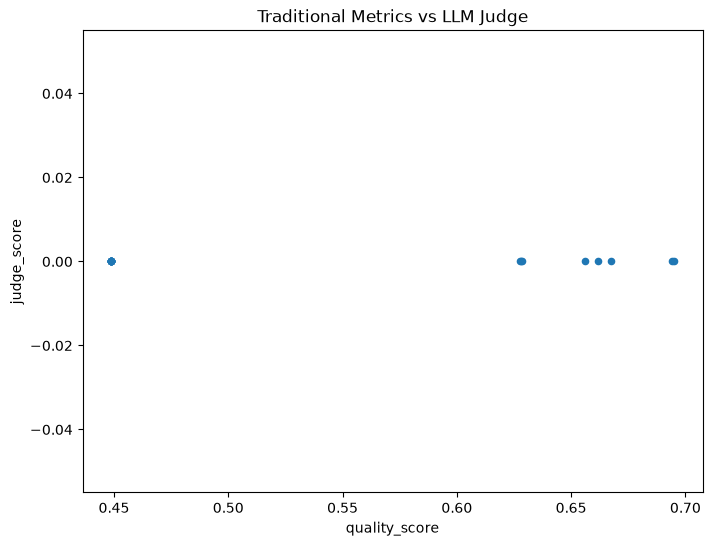

In [54]:
comparison_df.plot(kind="scatter", x="quality_score", y="judge_score", figsize=(8, 6))

plt.title("Traditional Metrics vs LLM Judge")

plt.show()

In [55]:
consistency_scores = []

for _ in range(3):

    score = llm_judge(question, ground_truth, generated_response)

    consistency_scores.append(score["overall_score"])

In [56]:
consistency_scores

[0, 0, 0]

In [57]:
import numpy as np

np.std(consistency_scores)

0.0

In [58]:
evaluation_df.to_csv("../evaluation_results/llm_judge_results.csv", index=False)

In [59]:
evaluation_df

,question,contexts,generated_response,ground_truth,question_length,answer_length,correctness,completeness,relevance,clarity,overall_score,reason,judge_quality,weighted_score
0,What is AWS?,AWS stands for Amazon Web Services. It is a cl...,AWS is Amazon's cloud platform.,"AWS is Amazon Web Services, a cloud computing ...",12.0,55.0,0,0,0,0,0,Parse Failed,Poor,0.0
1,What is Azure?,Microsoft Azure is a cloud platform offered by...,Azure is Microsoft's cloud service.,Microsoft Azure is a cloud computing platform ...,14.0,67.0,0,0,0,0,0,Parse Failed,Poor,0.0
2,What is Google Cloud?,Google Cloud Platform provides cloud computing...,Google Cloud offers cloud services.,Google Cloud Platform provides cloud computing...,21.0,56.0,0,0,0,0,0,Parse Failed,Poor,0.0
3,What is AWS?,AWS is a cloud platform.,AWS provides cloud services.,AWS is a cloud computing platform.,NaN,NaN,0,0,0,0,0,Parse Failed,Poor,0.0
4,What is Azure?,Azure is a cloud platform.,Azure provides cloud services.,Azure is a cloud computing platform.,NaN,NaN,0,0,0,0,0,Parse Failed,Poor,0.0
5,What is Google Cloud?,Google Cloud is a cloud platform.,Google Cloud provides cloud services.,Google Cloud is a cloud computing platform.,NaN,NaN,0,0,0,0,0,Parse Failed,Poor,0.0
6,What is Oracle Cloud?,Oracle Cloud is a cloud platform.,Oracle Cloud provides cloud services.,Oracle Cloud is a cloud computing platform.,NaN,NaN,0,0,0,0,0,Parse Failed,Poor,0.0
7,What is IBM Cloud?,IBM Cloud is a cloud platform.,IBM Cloud provides cloud services.,IBM Cloud is a cloud computing platform.,NaN,NaN,0,0,0,0,0,Parse Failed,Poor,0.0
8,Question 8,Sample context,Sample generated response,Sample ground truth,NaN,NaN,0,0,0,0,0,Parse Failed,Poor,0.0
9,Question 9,Sample context,Sample generated response,Sample ground truth,NaN,NaN,0,0,0,0,0,,Poor,0.0
